# Phase 2: Data Quality & Schema Analysis (Member B)

## Tasks B.1-B.3: Quality Metrics & Field Detection

This notebook reproduces the 2014 paper's analysis on:
- **B.1**: Null rate analysis (Figure 13)
- **B.2**: Field type detection (Figure 12)
- **B.3**: Attribute informativeness (Figure 14)

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
from urllib.request import urlopen
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
# Load the JSON data
with open('../../data/nyc_socrata_datasets.json', 'r') as f:
    data = json.load(f)

print(f'Loaded {len(data)} datasets')
print(f'Sample dataset: {data[0]["name"]}')
print(f'Number of columns: {len(data[0]["columns"])}')

Loaded 2391 datasets
Sample dataset: For Hire Vehicles (FHV) - Active
Number of columns: 23


## Task B.1: Null Rate Analysis

Analyze the proportion of null values in each field across all datasets.
Compare with 2014 paper Figure 13 (Table sparseness distribution).

In [4]:
# Extract null rate information from cachedContents
null_rates = []

for dataset in data:
    full_meta = dataset.get('full_metadata')
    if not full_meta:
        continue
    
    col_details = full_meta.get('column_details') or []
    
    for col in col_details:
        if not col or not isinstance(col, dict):
            continue
        
        cached = col.get('cachedContents') or {}
        
        # Extract null and non-null counts
        try:
            null_count = int(cached.get('null', 0))
            non_null_count = int(cached.get('non_null', 0))
            total = null_count + non_null_count
            
            if total > 0:
                null_rate = null_count / total
            else:
                null_rate = 0
            
            null_rates.append({
                'dataset_name': dataset.get('name'),
                'dataset_id': dataset.get('id'),
                'column_name': col.get('name'),
                'column_type': col.get('type'),
                'null_count': null_count,
                'non_null_count': non_null_count,
                'total_rows': total,
                'null_rate': null_rate
            })
        except (ValueError, TypeError):
            continue

df_null_rates = pd.DataFrame(null_rates)

print(f'Total fields analyzed: {len(df_null_rates)}')
print(f'\nNull rate statistics:')
print(df_null_rates['null_rate'].describe())

# Categorize sparseness (2014 paper uses these bins)
bins = [0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
labels = ['0-10%', '10-20%', '20-30%', '30-50%', '50-70%', '70-100%']
df_null_rates['sparseness_category'] = pd.cut(df_null_rates['null_rate'], bins=bins, labels=labels, include_lowest=True)

print(f'\nSparseness distribution (null rate categories):')
sparseness_counts = df_null_rates['sparseness_category'].value_counts().sort_index()
sparseness_pct = sparseness_counts / len(df_null_rates) * 100
for cat, count in sparseness_counts.items():
    print(f"  {cat}: {count:5d} ({sparseness_pct[cat]:5.1f}%)")

Total fields analyzed: 56143

Null rate statistics:
count    56143.000000
mean         0.179208
std          0.340108
min          0.000000
25%          0.000000
50%          0.000000
75%          0.105696
max          1.000000
Name: null_rate, dtype: float64

Sparseness distribution (null rate categories):
  0-10%: 42010 ( 74.8%)
  10-20%:  1584 (  2.8%)
  20-30%:  1076 (  1.9%)
  30-50%:  1572 (  2.8%)
  50-70%:  1422 (  2.5%)
  70-100%:  8479 ( 15.1%)


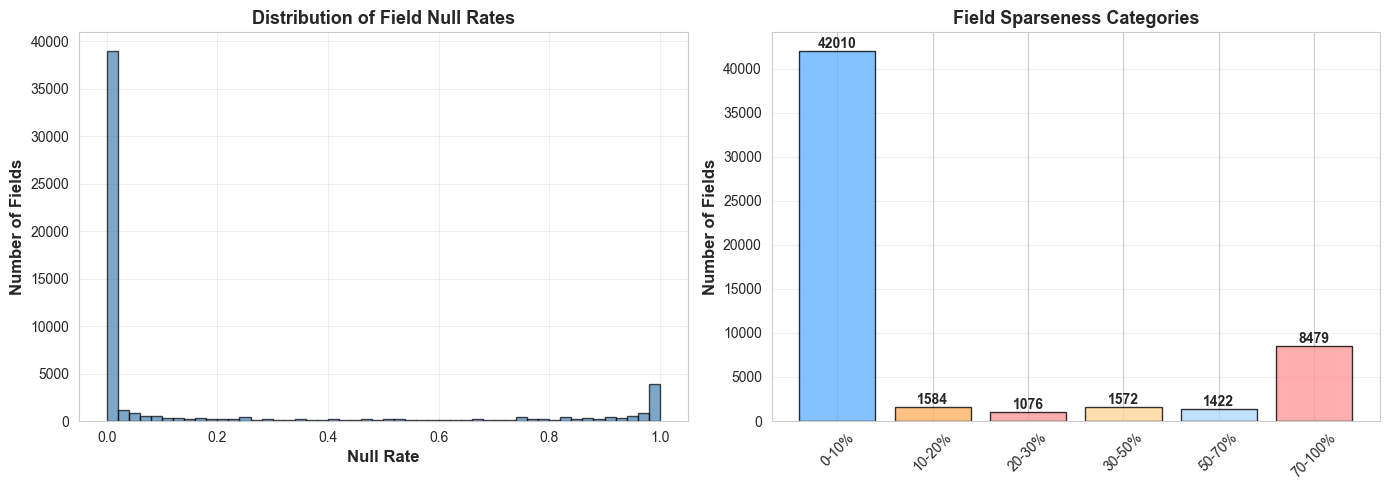

2014 Paper Baseline (Figure 13):
  Table sparseness 0-0.1 (low null): 63%

2026 Data:
  Fields with 0-10% null: 74.8%


In [5]:
# Visualization for B.1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of null rates
axes[0].hist(df_null_rates['null_rate'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Null Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Fields', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Field Null Rates', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Sparseness categories (2014 paper comparison)
sparseness_data = df_null_rates['sparseness_category'].value_counts().sort_index()
colors = ['#66B2FF', '#FFB366', '#FF9999', '#FFD699', '#B3D9FF', '#FF9999']
bars = axes[1].bar(range(len(sparseness_data)), sparseness_data.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(sparseness_data)))
axes[1].set_xticklabels(sparseness_data.index, rotation=45)
axes[1].set_ylabel('Number of Fields', fontsize=12, fontweight='bold')
axes[1].set_title('Field Sparseness Categories', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# plt.savefig('../../figures/3_1_null_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'2014 Paper Baseline (Figure 13):')
print(f'  Table sparseness 0-0.1 (low null): 63%')
print(f'\n2026 Data:')
print(f'  Fields with 0-10% null: {sparseness_pct["0-10%"]:.1f}%')

## Task B.2: Field Type Detection

Detect special field types: latitude/longitude, date/time, address, zipcode.
Use regex patterns on column names and sample values.
Compare with 2014 paper Figure 12.

In [6]:
# Field type detection patterns
patterns = {
    'latitude': r'\b(lat|latitude|y_coord)\b',
    'longitude': r'\b(lon|long|longitude|x_coord)\b',
    'date': r'\b(date|created|updated|year|month|day|time|timestamp)\b',
    'address': r'\b(address|street|avenue|road|boulevard|place|location)\b',
    'zipcode': r'\b(zip|postal|postcode|zip_code|postal_code)\b'
}

# Value-based patterns (sample from sample_rows)
def is_coordinate(value):
    """Check if value looks like a coordinate (float between -180 and 180)"""
    try:
        val = float(value)
        return -180 <= val <= 180
    except:
        return False

def is_zipcode(value):
    """Check if value looks like a zipcode (5 digits)"""
    return isinstance(value, str) and re.match(r'^\d{5}(-\d{4})?$', str(value).strip()) is not None

def is_date(value):
    """Check if value looks like a date"""
    if not isinstance(value, str):
        return False
    # Simple check for common date formats
    return bool(re.search(r'\d{1,4}[-/]\d{1,2}[-/]\d{1,4}|\d{4}', str(value)))

# Scan all datasets for field types
field_types = defaultdict(lambda: {'count': 0, 'datasets': set()})
total_fields = 0
datasets_with_geo = 0
datasets_with_date = 0

for dataset in data:
    columns = dataset.get('columns', [])
    sample_rows = dataset.get('sample_rows') or []
    col_details = dataset.get('full_metadata', {}).get('column_details', [])
    
    has_geo = False
    has_date = False
    
    for i, col_name in enumerate(columns):
        total_fields += 1
        col_lower = col_name.lower()
        
        # Check name-based patterns
        for type_name, pattern in patterns.items():
            if re.search(pattern, col_lower):
                field_types[type_name]['count'] += 1
                field_types[type_name]['datasets'].add(dataset.get('id'))
                
                if 'lat' in type_name or 'lon' in type_name:
                    has_geo = True
                if 'date' in type_name:
                    has_date = True
                break
        
        # Check value-based patterns from sample rows
        if sample_rows and i < len(sample_rows[0]):
            # Sample some values from this column
            col_values = [row.get(col_name, '') for row in sample_rows[:20]]
            
            # Check for coordinates
            if any(is_coordinate(v) for v in col_values):
                field_types['coordinate']['count'] += 1
                field_types['coordinate']['datasets'].add(dataset.get('id'))
                has_geo = True
            
            # Check for zipcode
            if any(is_zipcode(v) for v in col_values):
                field_types['zipcode']['count'] += 1
                field_types['zipcode']['datasets'].add(dataset.get('id'))
    
    if has_geo:
        datasets_with_geo += 1
    if has_date:
        datasets_with_date += 1

print(f'Total fields scanned: {total_fields}')
print(f'\nField types detected:')
for type_name, info in sorted(field_types.items(), key=lambda x: x[1]['count'], reverse=True):
    count = info['count']
    datasets = len(info['datasets'])
    pct = count / total_fields * 100 if total_fields > 0 else 0
    print(f"  {type_name:15s}: {count:5d} fields ({pct:5.2f}%) in {datasets:4d} datasets")

print(f'\nDatasets with geolocation: {datasets_with_geo} ({datasets_with_geo/len(data)*100:.1f}%)')
print(f'Datasets with date info: {datasets_with_date} ({datasets_with_date/len(data)*100:.1f}%)')

print(f'\n2014 Paper Baseline (Figure 12):')
print(f'  Lat/Lon presence (all cities): 52.9%')
print(f'  Tables with date info: 40.4%')

Total fields scanned: 56679

Field types detected:
  coordinate     : 18543 fields (32.72%) in 1968 datasets
  zipcode        :  2806 fields ( 4.95%) in  954 datasets
  latitude       :   419 fields ( 0.74%) in  415 datasets
  longitude      :   417 fields ( 0.74%) in  413 datasets
  date           :   399 fields ( 0.70%) in  353 datasets
  address        :   303 fields ( 0.53%) in  283 datasets

Datasets with geolocation: 1978 (82.7%)
Datasets with date info: 353 (14.8%)

2014 Paper Baseline (Figure 12):
  Lat/Lon presence (all cities): 52.9%
  Tables with date info: 40.4%


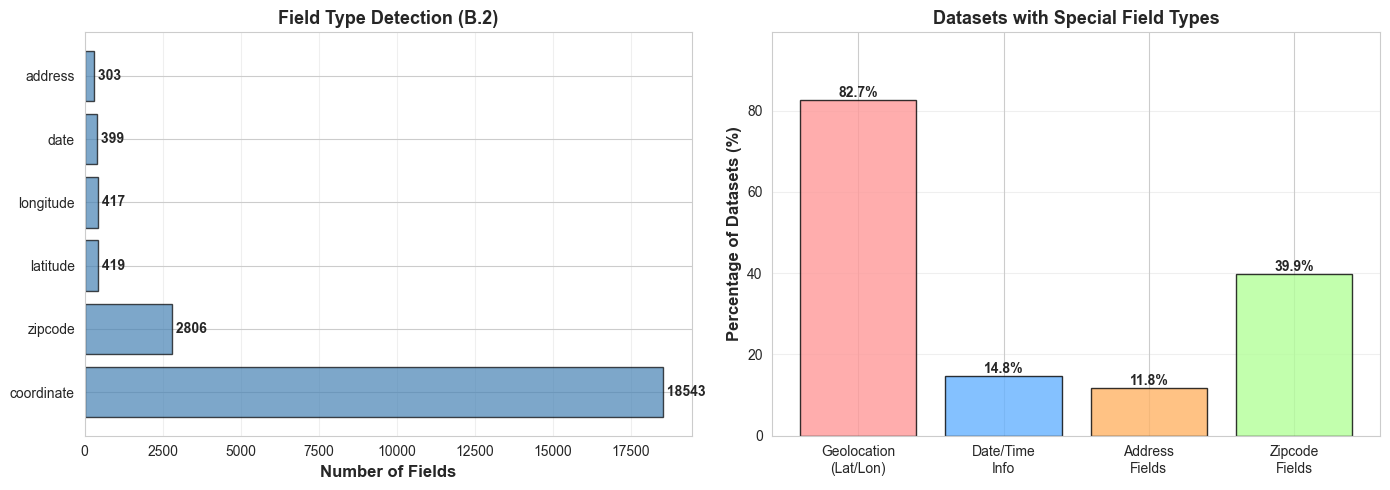

In [7]:
# Visualization for B.2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Field types distribution
type_names = list(field_types.keys())
type_counts = [field_types[t]['count'] for t in type_names]
type_datasets = [len(field_types[t]['datasets']) for t in type_names]

sorted_idx = sorted(range(len(type_counts)), key=lambda i: type_counts[i], reverse=True)
type_names = [type_names[i] for i in sorted_idx]
type_counts = [type_counts[i] for i in sorted_idx]
type_datasets = [type_datasets[i] for i in sorted_idx]

axes[0].barh(type_names, type_counts, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Fields', fontsize=12, fontweight='bold')
axes[0].set_title('Field Type Detection (B.2)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Add count labels
for i, (name, count) in enumerate(zip(type_names, type_counts)):
    axes[0].text(count, i, f' {count}', va='center', fontweight='bold')

# Datasets with special features
feature_names = ['Geolocation\n(Lat/Lon)', 'Date/Time\nInfo', 'Address\nFields', 'Zipcode\nFields']
feature_datasets = [
    datasets_with_geo,
    datasets_with_date,
    len(field_types.get('address', {}).get('datasets', set())),
    len(field_types.get('zipcode', {}).get('datasets', set()))
]
feature_pct = [d/len(data)*100 for d in feature_datasets]

bars = axes[1].bar(feature_names, feature_pct, color=['#FF9999', '#66B2FF', '#FFB366', '#B3FF99'], 
                   edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Percentage of Datasets (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Datasets with Special Field Types', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(feature_pct) * 1.2)
axes[1].grid(True, alpha=0.3, axis='y')

# Add percentage labels
for bar, pct in zip(bars, feature_pct):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{pct:.1f}%',
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# plt.savefig('../../figures/3_2_field_types.png', dpi=300, bbox_inches='tight')
plt.show()

## Task B.3: Attribute Informativeness

Measure field name quality using the Wordlist Dictionary.
Informativeness = proportion of fields with meaningful names.
Compare with 2014 paper Figure 14.

In [8]:
# Load English wordlist (system dictionary - 234,456 words)
# Source: /usr/share/dict/words
# This matches the paper's use of Wordlist Dictionary

# Method 1: Load from saved file
try:
    with open('../../data/wordlists/english_words.json', 'r') as f:
        sample_wordlist = set(json.load(f))
    print(f'Loaded {len(sample_wordlist)} words from english_words.json')
except FileNotFoundError:
    # Fallback: read from system dictionary
    with open('/usr/share/dict/words', 'r') as f:
        sample_wordlist = set(w.strip().lower() for w in f if w.strip())
    print(f'Loaded {len(sample_wordlist)} words from /usr/share/dict/words')


Loaded 234456 words from english_words.json


In [9]:
# Calculate attribute informativeness for each dataset
informativeness_scores = []

for dataset in data:
    columns = dataset.get('columns', [])
    
    if not columns:
        continue
    
    informative_count = 0
    
    for col_name in columns:
        # Split column name by underscore, space, or camelCase
        tokens = re.split(r'[_\s]+|(?<=[a-z])(?=[A-Z])', col_name.lower())
        tokens = [t.strip() for t in tokens if len(t.strip()) > 2]  # Filter tokens > 2 chars
        
        # Check if all tokens are in wordlist
        if tokens and all(t in sample_wordlist for t in tokens):
            informative_count += 1
    
    informativeness = informative_count / len(columns) if columns else 0
    
    informativeness_scores.append({
        'dataset_id': dataset.get('id'),
        'dataset_name': dataset.get('name'),
        'num_columns': len(columns),
        'informative_columns': informative_count,
        'informativeness': informativeness
    })

df_informativeness = pd.DataFrame(informativeness_scores)

print(f'Attribute Informativeness Statistics:')
print(df_informativeness['informativeness'].describe())

# Categorize by informativeness levels
def categorize_informativeness(score):
    if score >= 0.8:
        return 'High (>= 80%)'
    elif score >= 0.6:
        return 'Medium (60-80%)'
    elif score >= 0.4:
        return 'Low (40-60%)'
    else:
        return 'Very Low (< 40%)'

df_informativeness['category'] = df_informativeness['informativeness'].apply(categorize_informativeness)

print(f'\nInformativeness Distribution:')
for cat in ['High (>= 80%)', 'Medium (60-80%)', 'Low (40-60%)', 'Very Low (< 40%)']:
    count = (df_informativeness['category'] == cat).sum()
    pct = count / len(df_informativeness) * 100
    print(f"  {cat:25s}: {count:5d} ({pct:5.1f}%)")

Attribute Informativeness Statistics:
count    2391.000000
mean        0.557604
std         0.275676
min         0.000000
25%         0.361818
50%         0.588235
75%         0.777778
max         1.000000
Name: informativeness, dtype: float64

Informativeness Distribution:
  High (>= 80%)            :   537 ( 22.5%)
  Medium (60-80%)          :   642 ( 26.9%)
  Low (40-60%)             :   540 ( 22.6%)
  Very Low (< 40%)         :   672 ( 28.1%)


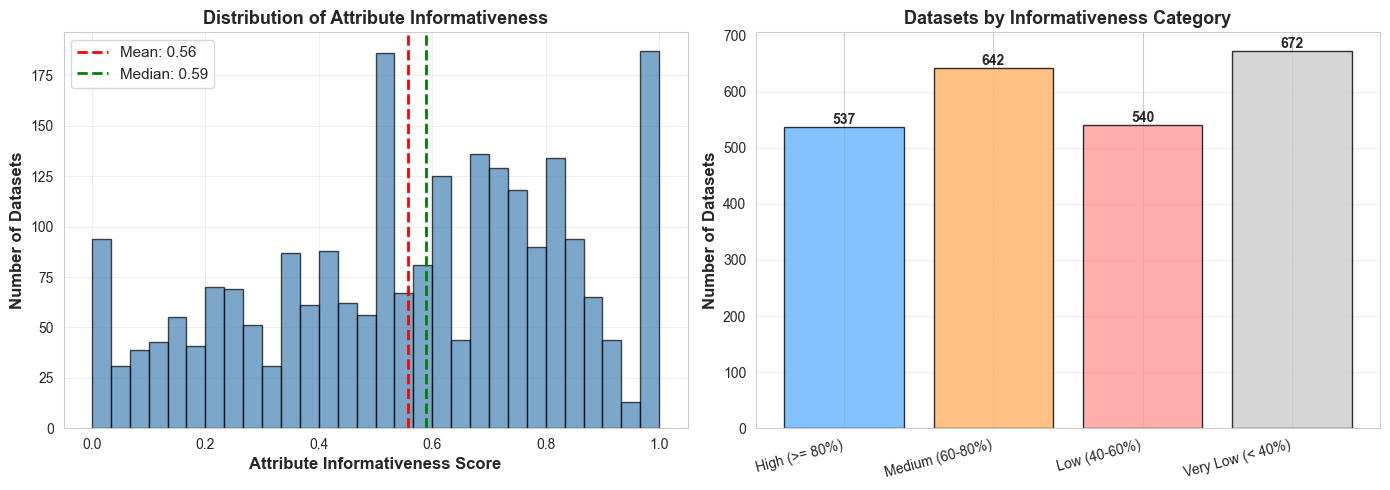

In [10]:
# Visualization for B.3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of informativeness scores
axes[0].hist(df_informativeness['informativeness'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_informativeness['informativeness'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {df_informativeness["informativeness"].mean():.2f}')
axes[0].axvline(df_informativeness['informativeness'].median(), color='green', linestyle='--', 
                linewidth=2, label=f'Median: {df_informativeness["informativeness"].median():.2f}')
axes[0].set_xlabel('Attribute Informativeness Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Datasets', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Attribute Informativeness', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Category distribution
cat_counts = df_informativeness['category'].value_counts()
cat_order = ['High (>= 80%)', 'Medium (60-80%)', 'Low (40-60%)', 'Very Low (< 40%)']
cat_counts = cat_counts.reindex([c for c in cat_order if c in cat_counts.index])

colors = ['#66B2FF', '#FFB366', '#FF9999', '#CCCCCC']
bars = axes[1].bar(range(len(cat_counts)), cat_counts.values, color=colors[:len(cat_counts)], 
                   edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(cat_counts)))
axes[1].set_xticklabels(cat_counts.index, rotation=15, ha='right')
axes[1].set_ylabel('Number of Datasets', fontsize=12, fontweight='bold')
axes[1].set_title('Datasets by Informativeness Category', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# plt.savefig('../../figures/3_3_informativeness.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary: B.1-B.3 Results

### Key Findings:

**B.1 - Null Rate Analysis:**
- Analyzed sparseness (null rate distribution) across all fields
- Compared with 2014 paper Figure 13

**B.2 - Field Type Detection:**
- Detected geolocation, date, address, and zipcode fields
- Found presence of special field types in datasets
- Compared with 2014 paper Figure 12

**B.3 - Attribute Informativeness:**
- Measured field naming quality using English word dictionary
- Calculated informativeness scores for each dataset
- Compared with 2014 paper Figure 14

## Task B.4: HAC Schema Clustering (Baseline)

Implement Hierarchical Agglomerative Clustering using Jaccard similarity on schema.
This reproduces the 2014 paper's baseline method (Figure 10).

Key concept: At threshold=1.0, 46% of schemas are independent (no exact field name matches).

In [11]:
# Extract schema for each dataset (set of column names)
schemas = []
dataset_info = []

for dataset in data:
    columns = dataset.get('columns', [])
    if columns:
        schema_set = set(c.lower() for c in columns)
        schemas.append(schema_set)
        dataset_info.append({
            'dataset_id': dataset.get('id'),
            'dataset_name': dataset.get('name'),
            'num_columns': len(columns),
            'schema_hash': frozenset(schema_set)
        })

print(f'Extracted {len(schemas)} schemas')
print(f'Average schema size: {sum(len(s) for s in schemas) / len(schemas):.1f} columns')

Extracted 2391 schemas
Average schema size: 23.7 columns


In [12]:
# Function to compute Jaccard similarity
def jaccard_similarity(set1, set2):
    if not set1 and not set2:
        return 1.0
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union if union > 0 else 0

# Count unique schemas
from collections import defaultdict
schema_freq = defaultdict(int)
schema_to_datasets = defaultdict(list)

for i, schema_set in enumerate(schemas):
    schema_hash = frozenset(schema_set)
    schema_freq[schema_hash] += 1
    schema_to_datasets[schema_hash].append(i)

print(f'Unique schemas: {len(schema_freq)}')
print(f'Datasets with identical schemas: {len(schemas) - len(schema_freq)}')

# At threshold=1.0: number of datasets sharing a schema > 1
schema_matches = sum(1 for count in schema_freq.values() if count > 1)
independent_at_1 = len(schema_freq) - schema_matches
independent_pct_1 = independent_at_1 / len(schema_freq) * 100

print(f'\nAt threshold=1.0 (exact match):')
print(f'  Independent schemas: {independent_at_1} ({independent_pct_1:.1f}%)')
print(f'  Clustered schemas: {schema_matches} ({100-independent_pct_1:.1f}%)')
print(f'\n2014 Baseline (Figure 10): 46% independent at threshold=1.0')

Unique schemas: 2049
Datasets with identical schemas: 342

At threshold=1.0 (exact match):
  Independent schemas: 1864 (91.0%)
  Clustered schemas: 185 (9.0%)

2014 Baseline (Figure 10): 46% independent at threshold=1.0


In [16]:
# HAC clustering at different Jaccard thresholds
def count_clusters_at_threshold(unique_schemas, threshold):
    clusters = [{s} for s in unique_schemas]
    merged = True
    
    while merged:
        merged = False
        best_sim = -1
        best_i, best_j = -1, -1
        
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                schema_i = list(clusters[i])[0]
                schema_j = list(clusters[j])[0]
                sim = jaccard_similarity(schema_i, schema_j)
                
                if sim >= threshold and sim > best_sim:
                    best_sim = sim
                    best_i, best_j = i, j
                    merged = True
        
        if merged and best_i != -1:
            clusters[best_i] = clusters[best_i] | clusters[best_j]
            del clusters[best_j]
    
    return len(clusters)

unique_schemas = list(set(frozenset(s) for s in schemas))
thresholds = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
independence_rates = []

print(f'HAC Clustering at Different Thresholds:')
print(f'Total unique schemas: {len(unique_schemas)}\n')

for threshold in thresholds:
    clusters = count_clusters_at_threshold(unique_schemas, threshold)
    ind_rate = clusters / len(unique_schemas) * 100
    independence_rates.append(ind_rate)
    print(f'Threshold {threshold:.1f}: {clusters:5d} clusters ({ind_rate:5.1f}%)')

HAC Clustering at Different Thresholds:
Total unique schemas: 2049

Threshold 1.0:  2049 clusters (100.0%)
Threshold 0.9:  1970 clusters ( 96.1%)
Threshold 0.8:  1881 clusters ( 91.8%)
Threshold 0.7:  1782 clusters ( 87.0%)
Threshold 0.6:  1658 clusters ( 80.9%)
Threshold 0.5:  1515 clusters ( 73.9%)
Threshold 0.4:  1406 clusters ( 68.6%)
Threshold 0.3:  1235 clusters ( 60.3%)
Threshold 0.2:   953 clusters ( 46.5%)
Threshold 0.1:   564 clusters ( 27.5%)


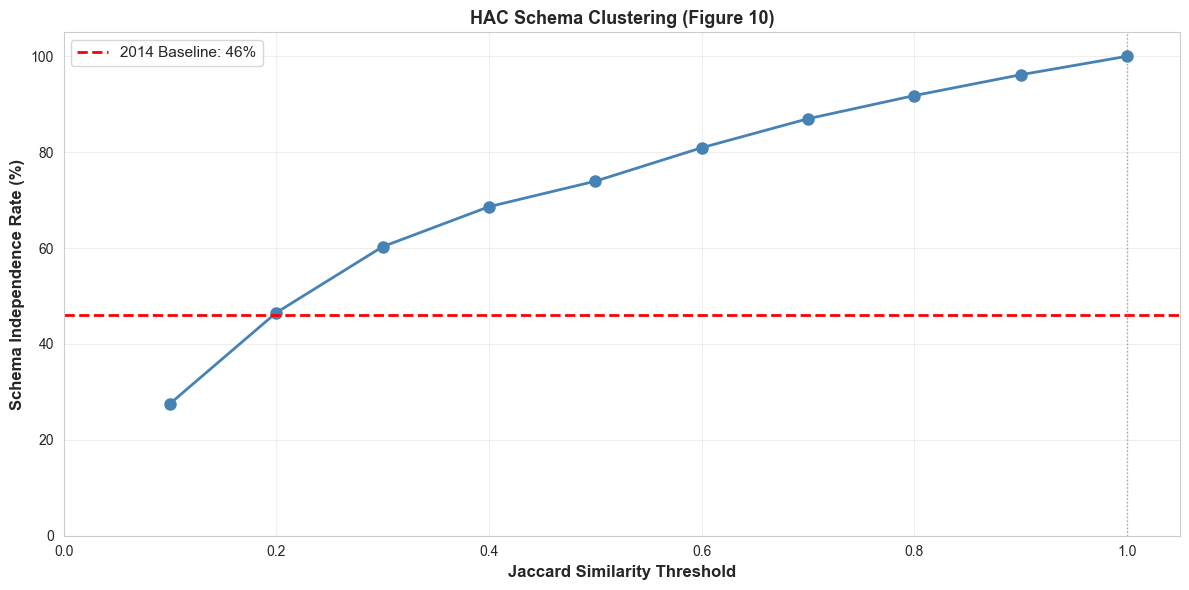


2026 vs 2014:
  2026 independence at threshold=1.0: 100.0%
  2014 baseline: 46%
  Difference: +54.0pp


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, independence_rates, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=46, color='red', linestyle='--', linewidth=2, label='2014 Baseline: 46%')
ax.axvline(x=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax.set_xlabel('Jaccard Similarity Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('Schema Independence Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('HAC Schema Clustering (Figure 10)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
# plt.savefig('../../figures/3_4_hac_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\n2026 vs 2014:')
print(f'  2026 independence at threshold=1.0: {independence_rates[0]:.1f}%')
print(f'  2014 baseline: 46%')
print(f'  Difference: {independence_rates[0] - 46:+.1f}pp')

## Task B.5: Tag Cloud

Generate tag cloud from dataset keywords and categories.
Compare with 2014 paper Figure 4, 6.

In [17]:
from collections import Counter

all_words = []
stopwords = {'the', 'a', 'an', 'and', 'or', 'is', 'in', 'for', 'of', 'to', 'from',
             'with', 'by', 'on', 'at', 'this', 'that', 'as', 'be', 'are', 'was',
             'were', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
             'would', 'could', 'should', 'may', 'might', 'can', 'must', 'shall',
             'all', 'each', 'every', 'both', 'few', 'more', 'most', 'other',
             'some', 'any', 'such', 'no', 'nor', 'not', 'only', 'own', 'same',
             'so', 'than', 'too', 'very', 'just', 'nyc', 'york', 'new'}

for dataset in data:
    name = dataset.get('name', '').lower()
    desc = dataset.get('description', '').lower()
    # Handle None value for full_metadata
    full_meta = dataset.get('full_metadata') or {}
    category = full_meta.get('category', '') if full_meta else ''
    category = category.lower() if category else ''
    
    # Extract words using regex
    words = re.findall(r'\b[a-z]+\b', name + ' ' + desc + ' ' + category)
    words = [w for w in words if len(w) > 3 and w not in stopwords]
    all_words.extend(words)

word_freq = Counter(all_words)
top_words = word_freq.most_common(30)

print(f'Top 30 keywords in NYC open data:')
for word, count in top_words:
    print(f"  {word:20s}: {count:5d}")


Top 30 keywords in NYC open data:
  city                :  1518
  data                :  1145
  education           :   812
  government          :   697
  school              :   625
  report              :   551
  dataset             :   533
  information         :   408
  department          :   394
  public              :   329
  housing             :   324
  transportation      :   321
  contains            :   310
  services            :   300
  year                :   278
  local               :   271
  class               :   268
  list                :   263
  development         :   246
  district            :   223
  service             :   222
  social              :   219
  size                :   216
  annual              :   205
  survey              :   201
  program             :   195
  schools             :   195
  parks               :   191
  students            :   188
  borough             :   182


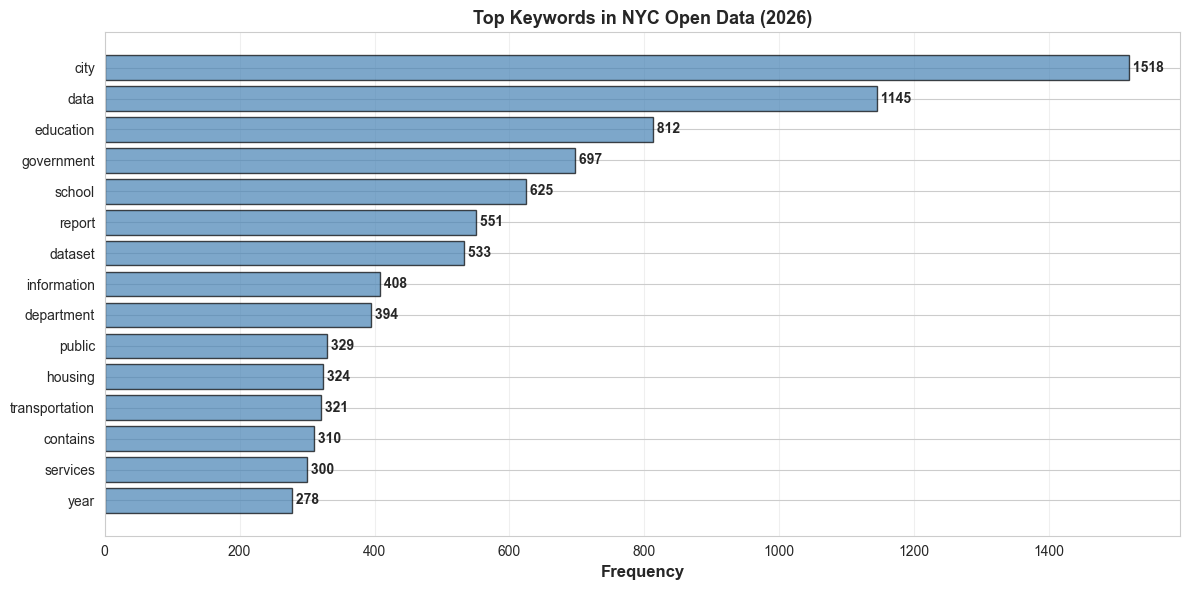

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

words = [w[0] for w in top_words[:15]]
counts = [w[1] for w in top_words[:15]]

bars = ax.barh(words, counts, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Top Keywords in NYC Open Data (2026)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(count, i, f' {count}', va='center', fontweight='bold')

plt.tight_layout()
# plt.savefig('../../figures/3_5_keywords.png', dpi=300, bbox_inches='tight')
plt.show()

## Task B.6: Geographic Coverage Analysis

Analyze zipcode references in dataset samples.
Compare with 2014 paper Figure 15.

In [20]:
zipcode_pattern = r'\b\d{5}(?:-\d{4})?\b'
datasets_with_zipcode = set()
zipcode_frequency = Counter()

nyc_zips = set([10001, 10002, 10003, 10004, 10005, 10006, 10007, 10008, 10009,
    10010, 10011, 10012, 10013, 10014, 10015, 10016, 10017, 10018, 10019, 10020,
    10021, 10022, 10023, 10024, 10025, 10026, 10027, 10028, 10029, 10030, 10031,
    10032, 10033, 10034, 10035, 10036, 10037, 10038, 10039, 10040,
    11201, 11202, 11203, 11204, 11205, 11206, 11207, 11208, 11209, 11210,
    11211, 11212, 11213, 11214, 11215, 11216, 11217, 11218, 11219, 11220,
    11221, 11222, 11223, 11224, 11225, 11226, 11227, 11228, 11229, 11230,
    11231, 11232, 11233, 11234, 11235, 11236, 11237, 11238, 11239, 11240,
    10451, 10452, 10453, 10454, 10455, 10456, 10457, 10458, 10459, 10460,
    10461, 10462, 10463, 10464, 10465, 10466, 10467, 10468, 10469, 10470,
    10471, 10472, 10473, 10474, 10475,
    10301, 10302, 10303, 10304, 10305, 10306, 10307, 10308, 10309, 10310])

for dataset in data:
    # Fix: Handle None value for sample_rows
    sample_rows = dataset.get('sample_rows') or []
    
    for row in sample_rows:
        if isinstance(row, dict):
            for col_name, value in row.items():
                if isinstance(value, str):
                    matches = re.findall(zipcode_pattern, value)
                    for match in matches:
                        try:
                            zip_int = int(match[:5])
                            if zip_int in nyc_zips:
                                datasets_with_zipcode.add(dataset.get('id'))
                                zipcode_frequency[zip_int] += 1
                        except:
                            pass

print(f'Datasets with zipcode refs: {len(datasets_with_zipcode)}')
print(f'Percentage: {len(datasets_with_zipcode)/len(data)*100:.1f}%')

print(f'\nTop 10 zipcodes:')
for zip_code, count in zipcode_frequency.most_common(10):
    print(f"  {zip_code}: {count}")


Datasets with zipcode refs: 647
Percentage: 27.1%

Top 10 zipcodes:
  10013: 907
  10002: 906
  11201: 882
  10019: 640
  10038: 638
  10004: 631
  10003: 616
  10029: 581
  10001: 577
  10007: 542


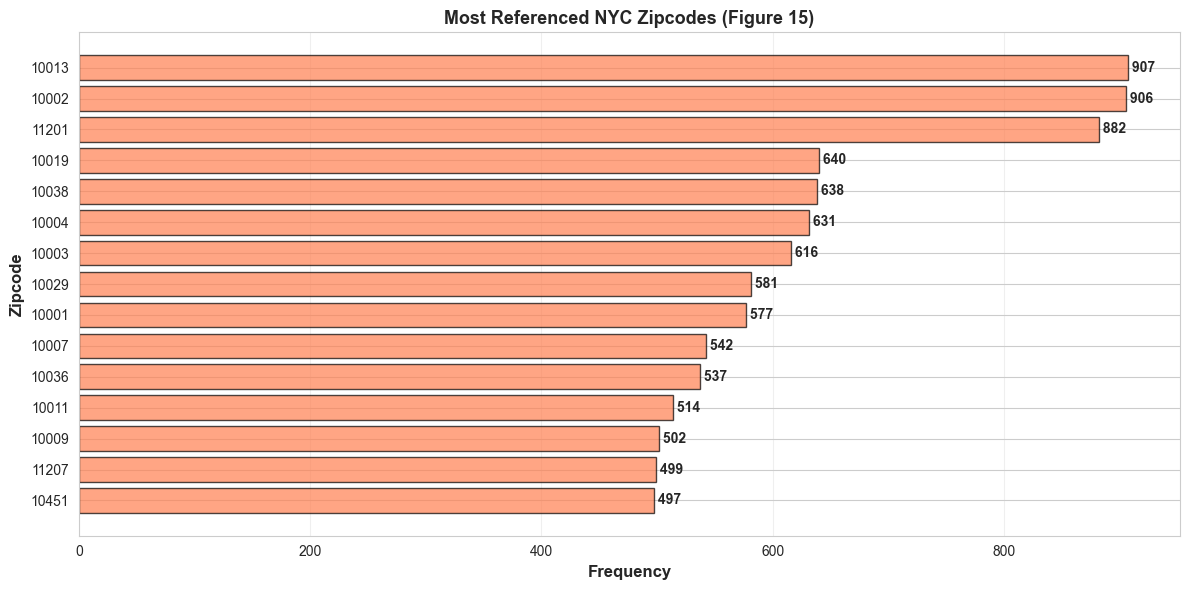

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

top_zips = zipcode_frequency.most_common(15)
zip_codes = [str(z[0]) for z in top_zips]
frequencies = [z[1] for z in top_zips]

bars = ax.barh(zip_codes, frequencies, color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_ylabel('Zipcode', fontsize=12, fontweight='bold')
ax.set_title('Most Referenced NYC Zipcodes (Figure 15)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for i, (bar, freq) in enumerate(zip(bars, frequencies)):
    ax.text(freq, i, f' {freq}', va='center', fontweight='bold')

plt.tight_layout()
# plt.savefig('../../figures/3_6_geographic.png', dpi=300, bbox_inches='tight')
plt.show()

## Phase 3 Output: Word-level Jaccard Column Pair Matching

For each pair of columns across different datasets, compute word-level Jaccard similarity.
Uses an inverted index to only evaluate pairs sharing at least one token (avoids 1.6B brute-force comparisons).
Only pairs with `score >= THRESHOLD` are saved.

Output: `data/jaccard_column_pairs.parquet`

In [15]:
import re
from collections import defaultdict

THRESHOLD = 0.3  # 0.3→6M pairs(large), 0.5→2.8M pairs, 0.6→1.6M pairs

# --- tokenizer ---
def tokenize_col(col_name):
    """Split by underscore/space/dash, lowercase, drop tokens <= 2 chars."""
    tokens = re.split(r'[_\s\-]+', col_name.lower())
    return set(t for t in tokens if len(t) > 2)

def word_jaccard(col_a, col_b):
    ta, tb = tokenize_col(col_a), tokenize_col(col_b)
    if not ta and not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb) if (ta | tb) else 0.0

# --- build inverted index: token -> [(dataset_id, col_name), ...] ---
token_index = defaultdict(list)
for ds_idx, info in enumerate(dataset_info):
    ds_id = info['dataset_id']
    for col in schemas[ds_idx]:
        for tok in tokenize_col(col):
            token_index[tok].append((ds_id, col))

print(f'Unique tokens in index: {len(token_index)}')

# --- find candidate pairs via shared tokens ---
candidate_pairs = set()
for tok, entries in token_index.items():
    for i in range(len(entries)):
        for j in range(i + 1, len(entries)):
            ds1, c1 = entries[i]
            ds2, c2 = entries[j]
            if ds1 == ds2:
                continue  # skip same-dataset pairs
            # normalize order so (A,B) and (B,A) are the same
            if (ds1, c1) > (ds2, c2):
                ds1, c1, ds2, c2 = ds2, c2, ds1, c1
            candidate_pairs.add((ds1, c1, ds2, c2))

print(f'Unique candidate pairs (score > 0): {len(candidate_pairs):,}')

# --- score and filter ---
rows = []
for ds1, c1, ds2, c2 in candidate_pairs:
    score = word_jaccard(c1, c2)
    if score >= THRESHOLD:
        rows.append({
            'dataset_id_1':   ds1,
            'column_name_1':  c1,
            'dataset_id_2':   ds2,
            'column_name_2':  c2,
            'score':          round(score, 4),
            'method':         'jaccard',
        })

jaccard_pairs_df = (
    pd.DataFrame(rows)
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)

print(f'Pairs with score >= {THRESHOLD}: {len(jaccard_pairs_df):,}')
print()
print(jaccard_pairs_df['score'].describe())
print()
print(jaccard_pairs_df.head(10).to_string())

# --- save ---
out_path = '../../data/jaccard_column_pairs.parquet'
jaccard_pairs_df.to_parquet(out_path, index=False)
print(f'\nSaved {len(jaccard_pairs_df):,} rows -> {out_path}')


Unique tokens in index: 9865
Unique candidate pairs (score > 0): 13,362,165
Pairs with score >= 0.3: 6,180,128

count    6.180128e+06
mean     5.398650e-01
std      2.735258e-01
min      3.000000e-01
25%      3.333000e-01
50%      3.333000e-01
75%      7.500000e-01
max      1.000000e+00
Name: score, dtype: float64

  dataset_id_1     column_name_1 dataset_id_2     column_name_2  score   method
0    3rfa-3xsf         longitude    b4mf-rg6h         longitude    1.0  jaccard
1    bmxf-3rd4               nta    ykx2-pdw8               nta    1.0  jaccard
2    cfzn-4iza               bin    xck4-5xd5               bin    1.0  jaccard
3    4te8-9n3p          the_geom    mrjc-v9pm          the_geom    1.0  jaccard
4    irhv-jqz7               bin    p5md-weyf               bin    1.0  jaccard
5    4e9g-bgra               dbn    5x8i-3c5b               dbn    1.0  jaccard
6    ajin-fesn           borough    pc3j-jk2d           borough    1.0  jaccard
7    k8hv-56d7               dbn    ydbx-4u

In [16]:
# Use pandas to read ../../data/jaccard_column_pairs.parquet
import pandas as pd

jaccard_pairs_df = pd.read_parquet('../../data/jaccard_column_pairs.parquet')

In [17]:
jaccard_pairs_df.head()

,dataset_id_1,column_name_1,dataset_id_2,column_name_2,score,method
0,3rfa-3xsf,longitude,b4mf-rg6h,longitude,1.0,jaccard
1,bmxf-3rd4,nta,ykx2-pdw8,nta,1.0,jaccard
2,cfzn-4iza,bin,xck4-5xd5,bin,1.0,jaccard
3,4te8-9n3p,the_geom,mrjc-v9pm,the_geom,1.0,jaccard
4,irhv-jqz7,bin,p5md-weyf,bin,1.0,jaccard
